In [1]:
import argparse
import pandas as pd
import numpy as np
import itertools
import torch
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from tqdm import tqdm

from attribscope.classifier.classifier import (
    MLPClassifier,
    train, infer,
    seed_everything,
    key_hidden
)
from attribscope.svd2.utils import (
    RepresentationStores,
    load_representations,
    _resolve_dir,
    split_data,
    compute_metrics,
    get_mistake_meta
)
from attribscope.svd2.computation import fit_all, score_all
# from attribscope.svd2.utils import run_metrics

In [2]:
REPS_ROOT = Path("outputs/representation-full")
DATA_ROOT = Path("data/ww")
MODEL     = ["llama-3.1-8b", "qwen3-8b"][1] # qwen3-8b
SUBSET    = ["algorithm-generated", "hand-crafted"][1] # hand-crafted
POOLING   = ["mean", "last"][1] # mean
SEED      = [1, 2, 3][0]
DEVICE    = torch.device("cuda:1")

In [3]:
# -------------------------------------------------------------------
# Hardcoded training configs
# -------------------------------------------------------------------
EPOCHS        = 500
LEARNING_RATE = 0.02
CLF_DIM       = 1024
BATCH_SIZE    = 512
WEIGHT_DECAY  = 3e-4
MOMENTUM      = 0.9
POS_WEIGHT    = None
LOGGING_STEPS = 100
VAL_METRIC    = "f1"

In [4]:
rep_dir = _resolve_dir(
    root_dir=REPS_ROOT,
    model=MODEL,
    subset=SUBSET,
    rep_type="hidden",
    loss=None,
    temperature=None,
    dir_type="representations"
)
data_dir = DATA_ROOT / SUBSET

print(f"Model:              {MODEL}")
print(f"Subset:             {SUBSET}")
print(f"Pooling:            {POOLING}")
print(f"Seed:               {SEED}")
print(f"Representation dir: {rep_dir}")
print(f"Data dir:           {data_dir}")

files = sorted(rep_dir.glob("*.safetensors"), key=lambda x: int(x.stem))
files = [file.name for file in files] # silent failure if not included
assert files, f"No .safetensors files in {rep_dir}"

train_files, test_files = split_data(files, 0.5, SEED)
train_files, val_files  = split_data(train_files, 0.8, SEED)

print(f"Train trajectories: {len(train_files)}")
print(f"Val trajectories:   {len(val_files)}")
print(f"Test trajectories:  {len(test_files)}")

rep_kwargs = dict(
    rep_dir=rep_dir,
    data_dir=data_dir,
    pooling=POOLING,
    weight_names="all",
    device=DEVICE,
)
train_reps = load_representations(**rep_kwargs, files=train_files)
val_reps   = load_representations(**rep_kwargs, files=val_files)
test_reps  = load_representations(**rep_kwargs, files=test_files)

LAYER_IDXS = sorted(train_reps.stores.keys(), key=key_hidden)
print(f"All positions: {LAYER_IDXS}\n")

Model:              qwen3-8b
Subset:             hand-crafted
Pooling:            last
Seed:               1
Representation dir: outputs/representation-full/hidden/qwen3-8b/reps/hand-crafted
Data dir:           data/ww/hand-crafted
Train trajectories: 23
Val trajectories:   6
Test trajectories:  29


Loading representations: 100%|██████████| 29/29 [00:01<00:00, 27.61it/s]


All positions: ['embed', 'act/0', 'act/1', 'act/2', 'act/3', 'act/4', 'act/5', 'act/6', 'act/7', 'act/8', 'act/9', 'act/10', 'act/11', 'act/12', 'act/13', 'act/14', 'act/15', 'act/16', 'act/17', 'act/18', 'act/19', 'act/20', 'act/21', 'act/22', 'act/23', 'act/24', 'act/25', 'act/26', 'act/27', 'act/28', 'act/29', 'act/30', 'act/31', 'act/32', 'act/33', 'act/34', 'act/35', 'act/35_normed']



## Modified SVD computation

In [55]:
from attribscope.svd2.utils import (
    load_representations,
    RepresentationStore,
    RepresentationStores,
    StoreKeeper,
)
from typing import Callable
from collections import defaultdict
from itertools import product as iproduct

In [56]:
from attribscope.svd2.utils import compute_metrics
def run_metrics(
    score_records: list[dict],   # output of score_all
    keeper:        StoreKeeper,
    ks:            list[int],
) -> pd.DataFrame:
    """Evaluate score records against ground-truth mistake steps.

    Expands each score record across (direction × k), calling compute_metrics
    once per (record, direction) since it computes all ks in a single pass.

    `score_records` are the results from running `score_all`
    Each row in score_records has the format:
    {
        "weight":   store.name,
        "pooling":  store.pooling,
        "method":   method,
        "c_begin":  c_begin,
        "c_end":    c_end,
        "centered": centered,
        "scores":   scores,      # (T,) np.ndarray
    })

    Returns
    -------
    Flat DataFrame, one row per (weight × method × c × centered × direction × k).
    """
    mistake_indices, mistake_roles = get_mistake_meta(keeper)
    rows = []
    for rec in score_records:
        for direction in ("asc", "desc"):
            m = compute_metrics(
                rec["scores"], keeper,
                mistake_indices, mistake_roles,
                ks, direction,
            )
            rows.extend([{
                "weight":    rec["weight"],
                "pooling":   rec["pooling"],
                "method":    rec["method"],
                "c_begin":   rec["c_begin"],
                "c_end":     rec["c_end"],
                "centered":  rec["centered"],
                "direction": direction,
                "k":         k,
                "step_acc":  m[f"step@{k}_{direction}"],
                "agent_acc": m[f"agent@{k}_{direction}"],
            } for k in ks])
    return pd.DataFrame(rows)

In [57]:
def truncated_projection_svd(
    R: torch.Tensor, # (T, d) matrix of row reps to score
    V: torch.Tensor, # (d, c) matrix of top-c right singular vectors from G
    c_begin: int = 0,
    c_end:   int = 20,
    ref: torch.Tensor | None = None, # (d,) mean gradient for centering, if desired
) -> torch.Tensor:
    assert 0 <= c_begin < c_end <= V.shape[1], \
        f"Invalid range [{c_begin}:{c_end}] for V with {V.shape[1]} components"
    R_f = R.float()
    if ref is not None:
        R_f = R_f - ref
    scores = (R_f @ V[:, c_begin:c_end]).square().mean(dim=1).to(R.dtype)
    return scores

In [58]:
SCORING_FNS = {
    "trunc_proj": truncated_projection_svd
}

In [59]:
def get_bounds(N):
    return [(a, b) for a in range(N) for b in range(a + 1, N + 1)]

def score_one(
    store:              RepresentationStore,
    svd_entry:          dict,
    n_components:       int,
    scoring_fns:        dict[str, Callable],
    device:             torch.device = torch.device("cuda"),
) -> list[dict]:
    R    = store.R.float().to(device)
    rows = []

    # Projection-based scores over (centered × method × (c_begin, c_end))
    bounds = get_bounds(n_components)
    combos = list(iproduct((True, False), scoring_fns.items(), bounds))
    for centered, (method, fn), (c_begin, c_end) in combos:
        V      = svd_entry["V_centered" if centered else "V_raw"].to(device)
        ref    = svd_entry["ref"].to(device) if centered else None
        scores = fn(R, V, c_begin, c_end, ref).cpu().numpy()
        rows.append({
            "weight":   store.name,
            "pooling":  store.pooling,
            "method":   method,
            "c_begin":  c_begin,
            "c_end":    c_end,
            "centered": centered,
            "scores":   scores,
        })

    # Representation norm baseline (no SVD components involved)
    for centered in (True, False):
        ref    = svd_entry["ref"].to(device) if centered else None
        R_eval = R - ref if ref is not None else R
        norms  = R_eval.norm(dim=1).cpu().numpy()
        rows.append({
            "weight":   store.name,
            "pooling":  store.pooling,
            "method":   "norm",
            "c_begin":  None,
            "c_end":    None,
            "centered": centered,
            "scores":   norms,
        })

    return rows

def score_all(
    stores:             dict,
    svd:                dict,
    n_components:       int,
    scoring_fns:        dict[str, Callable],
    device:             torch.device,
) -> list[dict]:
    """Compute anomaly scores for every store.

    Returns
    -------
    Flat list of score records (see score_one).
    """
    records = []
    for s in stores.values():
        if s.pooling not in svd or s.name not in svd[s.pooling]:
            continue
        records.extend(score_one(
            store        = s,
            svd_entry    = svd[s.pooling][s.name],
            n_components = n_components,
            scoring_fns  = scoring_fns,
            device       = device,
        ))
    return records

In [61]:
def precompute_svd(
    train_reps: RepresentationStores,
    val_reps:   RepresentationStores,
    test_reps:  RepresentationStores,
    n_components: int = 10,
    scoring_fns: dict[str, Callable] = None,
    device: torch.device = torch.device("cuda")
):
    svd_components = fit_all(train_reps.stores, n_components=n_components)
    score_kwargs = dict(
        svd=svd_components,
        n_components=n_components,
        scoring_fns=scoring_fns,
        device=device
    )
    train_scores = score_all(train_reps.stores, **score_kwargs)
    val_scores   = score_all(val_reps.stores,   **score_kwargs)
    test_scores  = score_all(test_reps.stores,  **score_kwargs)

    val_df  = run_metrics(val_scores,  keeper=val_reps.keeper,  ks=[1])
    test_df = run_metrics(test_scores, keeper=test_reps.keeper, ks=[1])
    merged_df = pd.merge(
        val_df, test_df, suffixes=('_val', '_test'),
        on=['weight', 'pooling', 'method', 'c_begin', 
            'c_end', 'centered', 'direction', 'k'],
    )

    return dict(
        svd_components = svd_components,
        svd_accuracy   = merged_df,
        train_scores   = train_scores,
        val_scores     = val_scores,
        test_scores    = test_scores
    )

In [62]:
precomputed_svd = precompute_svd(
    train_reps=train_reps,
    val_reps=val_reps,
    test_reps=test_reps,
    n_components=20,
    scoring_fns=SCORING_FNS,
    device=DEVICE
)

SVD fit: 100%|██████████| 38/38 [00:00<00:00, 71.50it/s]


In [63]:
svd_accuracy = precomputed_svd["svd_accuracy"]
svd_accuracy = svd_accuracy[svd_accuracy["direction"] == "asc"]
svd_accuracy = svd_accuracy.sort_values("step_acc_test", ascending=False)

In [70]:
svd_accuracy.to_csv("outputs/temp/tmp.tsv", sep="\t", index=False)

In [65]:
svd_accuracy.head(20)

,weight,pooling,method,c_begin,c_end,centered,direction,k,step_acc_val,agent_acc_val,step_acc_test,agent_acc_test
13548,act/23,last,trunc_proj,1.0,4.0,True,asc,1,0.166667,0.666667,0.241379,0.620690
5988,act/15,last,trunc_proj,2.0,4.0,True,asc,1,0.166667,0.500000,0.206897,0.758621
13972,act/23,last,trunc_proj,1.0,6.0,False,asc,1,0.000000,0.166667,0.206897,0.448276
5952,act/15,last,trunc_proj,1.0,4.0,True,asc,1,0.166667,0.666667,0.206897,0.758621
28774,act/7,last,trunc_proj,2.0,3.0,True,asc,1,0.000000,0.500000,0.206897,0.620690
25434,act/35_normed,last,trunc_proj,3.0,4.0,True,asc,1,0.000000,0.666667,0.206897,0.517241
14008,act/23,last,trunc_proj,2.0,6.0,False,asc,1,0.166667,0.500000,0.206897,0.551724
14006,act/23,last,trunc_proj,2.0,5.0,False,asc,1,0.166667,0.833333,0.206897,0.620690
14046,act/23,last,trunc_proj,3.0,8.0,False,asc,1,0.166667,0.500000,0.206897,0.586207
15310,act/25,last,trunc_proj,3.0,6.0,True,asc,1,0.166667,0.166667,0.206897,0.586207


In [9]:
precomputed_svd = precompute_svd(train_reps, val_reps, test_reps,
                                    n_components=20, device=DEVICE)
train_scores = precomputed_svd["train_scores"]
val_scores   = precomputed_svd["val_scores"]
svd_accuracy = precomputed_svd["svd_accuracy"]

svd_accuracy = svd_accuracy[svd_accuracy["direction"] == "asc"]
svd_accuracy = svd_accuracy.sort_values("step_acc_test", ascending=False)

SVD fit: 100%|██████████| 38/38 [00:00<00:00, 73.65it/s]


In [11]:
svd_accuracy.query("centered == True")

,weight,pooling,method,c,centered,direction,k,step_acc_val,agent_acc_val,step_acc_test,agent_acc_test
1680,act/28,mean,proj,1,True,asc,1,0.000000,0.166667,0.172414,0.448276
2964,embed,mean,proj,3,True,asc,1,0.166667,1.000000,0.172414,0.586207
2160,act/33,mean,proj,1,True,asc,1,0.000000,0.500000,0.137931,0.448276
1600,act/27,mean,proj,1,True,asc,1,0.000000,0.166667,0.137931,0.413793
2980,embed,mean,proj,11,True,asc,1,0.000000,0.500000,0.103448,0.482759
...,...,...,...,...,...,...,...,...,...,...,...
1702,act/28,mean,proj,12,True,asc,1,0.000000,0.166667,0.000000,0.344828
1704,act/28,mean,proj,13,True,asc,1,0.166667,0.166667,0.000000,0.344828
1706,act/28,mean,proj,14,True,asc,1,0.166667,0.166667,0.000000,0.344828
1708,act/28,mean,proj,15,True,asc,1,0.166667,0.166667,0.000000,0.344828


## Here we read the new results again

In [73]:
from pathlib import Path
import pandas as pd

MODEL = ["llama-3.1-8b", "qwen3-8b"][1]
SUBSET = ["algorithm-generated", "hand-crafted"][1]
REP_TYPE = "hidden"

base = Path(f"outputs/classifier-full-noval/{REP_TYPE}/")
svd_pattern = f"{MODEL}/metrics/{SUBSET}/svd_*.tsv"
clf_pattern = f"{MODEL}/metrics/{SUBSET}/classifier_*.tsv"

frames = []
for path in sorted(base.glob(svd_pattern)):
    parts = path.stem.split("_")
    pooling = parts[1][len("pooling-"):]
    seed = int(parts[2][len("seed-"):])
    df = pd.read_csv(path, sep="\t").assign(
        pooling=pooling, seed=seed
    )
    frames.append(df)
    
svd_df = pd.concat(frames, ignore_index=True)

frames = []
for path in sorted(base.glob(clf_pattern)):
    parts = path.stem.split("_")
    pooling = parts[1][len("pooling-"):]
    seed = int(parts[2][len("seed-"):])
    df = pd.read_csv(path, sep="\t").assign(
        pooling=pooling, seed=seed
    )
    frames.append(df)
    
clf_df = pd.concat(frames, ignore_index=True)
oracle_df = clf_df.query("labels == 'oracle'")
pseudo_df = clf_df.query("labels == 'pseudo'")

In [74]:
oracle_df = oracle_df[[
    "threshold", "weight", "pooling", "c", "centered", "direction", "seed",
    "test_step_acc", "test_agent_acc"
]]
oracle_df = oracle_df.rename(columns={"test_step_acc": "step_acc", "test_agent_acc": "agent_acc"})
# print(oracle_df.head().to_string())
# oracle_df = oracle_df[oracle_df["seed"] != 3]
idx = (oracle_df.groupby(['pooling', 'seed'])['step_acc'].idxmax())
oracle_report = oracle_df.loc[idx].reset_index(drop=True)
oracle_report.loc["average"] = oracle_report.filter(like="_acc").mean()
oracle_report

,threshold,weight,pooling,c,centered,direction,seed,step_acc,agent_acc
0,0.0,act/11,last,4.0,True,asc,1.0,0.291667,0.541667
1,0.0,act/7,last,2.0,False,asc,2.0,0.250000,0.708333
2,0.0,act/12,last,4.0,True,asc,3.0,0.208333,0.625000
3,0.0,act/28,mean,13.0,False,asc,1.0,0.333333,0.708333
4,0.0,act/25,mean,3.0,False,asc,2.0,0.291667,0.583333
5,0.0,act/22,mean,2.0,False,asc,3.0,0.208333,0.666667
average,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.263889,0.638889


In [75]:
pseudo_df = pseudo_df[[
    "threshold", "weight", "pooling", "c", "centered", "direction", "seed",
    "test_step_acc", "test_agent_acc"
]]
pseudo_df = pseudo_df.rename(columns={"test_step_acc": "step_acc", "test_agent_acc": "agent_acc"})
# print(pseudo_df.head().to_string())
# pseudo_df = pseudo_df[pseudo_df["seed"] != 3]
idx = (pseudo_df.groupby(['pooling', 'seed'])['step_acc'].idxmax())
pseudo_report = pseudo_df.loc[idx].reset_index(drop=True)
pseudo_report.loc["average"] = pseudo_report.filter(like="_acc").mean()
pseudo_report

,threshold,weight,pooling,c,centered,direction,seed,step_acc,agent_acc
0,0.075,act/32,last,20.0,False,asc,1.0,0.291667,0.666667
1,0.010,act/2,last,3.0,True,asc,2.0,0.333333,0.666667
2,0.175,act/27,last,19.0,False,asc,3.0,0.166667,0.583333
3,0.175,act/23,mean,2.0,False,asc,1.0,0.375000,0.666667
4,0.200,act/35,mean,2.0,False,asc,2.0,0.333333,0.791667
5,0.010,act/20,mean,2.0,False,asc,3.0,0.208333,0.583333
average,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.284722,0.659722


In [ ]:
# svd_df = svd_df[svd_df["centered"] == True]
# svd_df = svd_df[svd_df["seed"] != 3]
svd_df["threshold"] = -1
svd_df = svd_df[[
    "threshold", "weight", "pooling", "c", "centered", "direction", "seed",
    "test_step_acc", "test_agent_acc"
]]
idx = (svd_df.groupby(['pooling', 'seed'])['step_acc'].idxmax())
svd_report = svd_df.loc[idx].reset_index(drop=True)
svd_report.loc["average"] = svd_report.filter(like="_acc").mean()
svd_report

,weight,pooling,method,c,centered,direction,k,step_acc,agent_acc,seed
0,act/26,last,proj,9.0,False,asc,1.0,0.291667,0.708333,1.0
1,act/3,last,proj,4.0,True,asc,1.0,0.291667,0.583333,2.0
2,act/10,last,proj,15.0,False,asc,1.0,0.125000,0.375000,3.0
3,act/23,mean,proj,2.0,False,asc,1.0,0.375000,0.708333,1.0
4,act/35,mean,proj,2.0,False,asc,1.0,0.291667,0.750000,2.0
5,act/15,mean,proj,2.0,False,asc,1.0,0.208333,0.541667,3.0
average,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.263889,0.611111,NaN


## Another one with more seletective SVD components.

In [5]:
from pathlib import Path
import pandas as pd

MODEL = ["llama-3.1-8b", "qwen3-8b"][1]
SUBSET = ["algorithm-generated", "hand-crafted"][1]
REP_TYPE = "hidden"
c_cols = [["c"], ["c_begin", "c_end"]][0]

base = Path(f"outputs/classifier-full-noval/{REP_TYPE}/")
svd_pattern = f"{MODEL}/metrics/{SUBSET}/svd_*.tsv"
clf_pattern = f"{MODEL}/metrics/{SUBSET}/classifier_*.tsv"

frames = []
for path in sorted(base.glob(svd_pattern)):
    parts = path.stem.split("_")
    pooling = parts[1][len("pooling-"):]
    seed = int(parts[2][len("seed-"):])
    df = pd.read_csv(path, sep="\t").assign(
        pooling=pooling, seed=seed
    )
    frames.append(df)
    
svd_df = pd.concat(frames, ignore_index=True)

frames = []
for path in sorted(base.glob(clf_pattern)):
    parts = path.stem.split("_")
    pooling = parts[1][len("pooling-"):]
    seed = int(parts[2][len("seed-"):])
    df = pd.read_csv(path, sep="\t").assign(
        pooling=pooling, seed=seed
    )
    frames.append(df)
    
clf_df = pd.concat(frames, ignore_index=True)
oracle_df = clf_df.query("labels == 'oracle'")
pseudo_df = clf_df.query("labels == 'pseudo'")

In [6]:
oracle_df = oracle_df[[
    "threshold", "weight", "pooling", *c_cols, "centered", "direction", "seed",
    "test_step_acc", "test_agent_acc"
]]
oracle_df = oracle_df.rename(columns={"test_step_acc": "step_acc", "test_agent_acc": "agent_acc"})
# print(oracle_df.head().to_string())
# oracle_df = oracle_df[oracle_df["seed"] != 3]
idx = (oracle_df.groupby(['pooling', 'seed'])['step_acc'].idxmax())
oracle_report = oracle_df.loc[idx].reset_index(drop=True)[:]
oracle_report.loc["average"] = oracle_report.filter(like="_acc").mean()
oracle_report

,threshold,weight,pooling,c,centered,direction,seed,step_acc,agent_acc
0,0.0,act/11,last,4.0,True,asc,1.0,0.291667,0.541667
1,0.0,act/7,last,2.0,False,asc,2.0,0.250000,0.708333
2,0.0,act/12,last,4.0,True,asc,3.0,0.208333,0.625000
3,0.0,act/28,mean,13.0,False,asc,1.0,0.333333,0.708333
4,0.0,act/25,mean,3.0,False,asc,2.0,0.291667,0.583333
5,0.0,act/22,mean,2.0,False,asc,3.0,0.208333,0.666667
average,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.263889,0.638889


In [7]:
pseudo_df = pseudo_df[[
    "threshold", "weight", "pooling",  *c_cols, "centered", "direction", "seed",
    "test_step_acc", "test_agent_acc"
]]
pseudo_df = pseudo_df.rename(columns={"test_step_acc": "step_acc", "test_agent_acc": "agent_acc"})
# print(pseudo_df.head().to_string())
# pseudo_df = pseudo_df[pseudo_df["seed"] != 3]
idx = (pseudo_df.groupby(['pooling', 'seed'])['step_acc'].idxmax())
pseudo_report = pseudo_df.loc[idx].reset_index(drop=True)[:]
pseudo_report.loc["average"] = pseudo_report.filter(like="_acc").mean()
pseudo_report

,threshold,weight,pooling,c,centered,direction,seed,step_acc,agent_acc
0,0.075,act/32,last,20.0,False,asc,1.0,0.291667,0.666667
1,0.010,act/2,last,3.0,True,asc,2.0,0.333333,0.666667
2,0.175,act/27,last,19.0,False,asc,3.0,0.166667,0.583333
3,0.175,act/23,mean,2.0,False,asc,1.0,0.375000,0.666667
4,0.200,act/35,mean,2.0,False,asc,2.0,0.333333,0.791667
5,0.010,act/20,mean,2.0,False,asc,3.0,0.208333,0.583333
average,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.284722,0.659722


In [8]:
# svd_df = svd_df[svd_df["centered"] == True]
# svd_df = svd_df[svd_df["seed"] != 3]
idx = (svd_df.groupby(['pooling', 'seed'])['step_acc'].idxmax())
svd_report = svd_df.loc[idx].reset_index(drop=True)[:]
svd_report.loc["average"] = svd_report.filter(like="_acc").mean()
svd_report

,weight,pooling,method,c,centered,direction,k,step_acc,agent_acc,seed
0,act/26,last,proj,9.0,False,asc,1.0,0.291667,0.708333,1.0
1,act/3,last,proj,4.0,True,asc,1.0,0.291667,0.583333,2.0
2,act/10,last,proj,15.0,False,asc,1.0,0.125000,0.375000,3.0
3,act/23,mean,proj,2.0,False,asc,1.0,0.375000,0.708333,1.0
4,act/35,mean,proj,2.0,False,asc,1.0,0.291667,0.750000,2.0
5,act/15,mean,proj,2.0,False,asc,1.0,0.208333,0.541667,3.0
average,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.263889,0.611111,NaN


## Plot PCA

In [1]:
from attribscope.classifier.classifier import (
    MLPClassifier,
    train, infer, quick_eval,
    seed_everything
)
from attribscope.svd2.utils import (
    load_representations,
    _resolve_dir,
    split_data,
    compute_metrics,
    get_mistake_meta
)
import torch
from pathlib import Path
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

## Reproduce the best scores

In [9]:
import argparse
import pandas as pd
import numpy as np
import itertools
import torch
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from tqdm import tqdm

from attribscope.classifier.classifier import (
    MLPClassifier,
    train, infer,
    seed_everything,
    key_hidden
)
from attribscope.svd2.utils import (
    RepresentationStores,
    load_representations,
    _resolve_dir,
    split_data,
    get_mistake_meta
)
from attribscope.svd2.computation import fit_all
from attribscope.svd2.patch import (
    score_all, compute_metrics,
    gather_configs_and_metrics,
    truncated_projection_svd
)
from experiments.classifier.run_all_positions_noval_trunc import (
    precompute_svd, prepare_data, get_metrics
)

SCORING_FNS = {"trunc_proj": truncated_projection_svd}

In [10]:
REPS_ROOT = Path("outputs/representation-full")
DATA_ROOT = Path("data/ww")
# MODEL     = ["llama-3.1-8b", "qwen3-8b"][1] # qwen3-8b
# SUBSET    = ["algorithm-generated", "hand-crafted"][1] # hand-crafted
POOLING   = ["mean", "last"][1] # mean
SEED      = [1, 2, 3][0]
DEVICE    = torch.device("cuda:1")

In [12]:
# -------------------------------------------------------------------
# Hardcoded training configs
# -------------------------------------------------------------------
EPOCHS        = 500
LEARNING_RATE = 0.02
CLF_DIM       = 1024
BATCH_SIZE    = 512
WEIGHT_DECAY  = 3e-4
MOMENTUM      = 0.9
POS_WEIGHT    = None
LOGGING_STEPS = 100
VAL_METRIC    = "f1"

In [13]:
rep_dir = _resolve_dir(
    root_dir=REPS_ROOT,
    model=MODEL,
    subset=SUBSET,
    rep_type="hidden",
    loss=None,
    temperature=None,
    dir_type="representations"
)
data_dir = DATA_ROOT / SUBSET

print(f"Model:              {MODEL}")
print(f"Subset:             {SUBSET}")
print(f"Pooling:            {POOLING}")
print(f"Seed:               {SEED}")
print(f"Representation dir: {rep_dir}")
print(f"Data dir:           {data_dir}")

files = sorted(rep_dir.glob("*.safetensors"), key=lambda x: int(x.stem))
files = [file.name for file in files] # silent failure if not included
assert files, f"No .safetensors files in {rep_dir}"

train_files, test_files = split_data(files, 0.6, SEED)

print(f"Train trajectories: {len(train_files)}")
print(f"Test trajectories:  {len(test_files)}")

rep_kwargs = dict(
    rep_dir=rep_dir,
    data_dir=data_dir,
    pooling=POOLING,
    weight_names="all",
    device=DEVICE,
)
train_reps = load_representations(**rep_kwargs, files=train_files)
test_reps  = load_representations(**rep_kwargs, files=test_files)

LAYER_IDXS = sorted(train_reps.stores.keys(), key=key_hidden)
print(f"All positions: {LAYER_IDXS}\n")

Model:              qwen3-8b
Subset:             hand-crafted
Pooling:            last
Seed:               1
Representation dir: outputs/representation-full/hidden/qwen3-8b/reps/hand-crafted
Data dir:           data/ww/hand-crafted
Train trajectories: 34
Test trajectories:  24


Loading representations: 100%|██████████| 24/24 [00:00<00:00, 27.87it/s]


All positions: ['embed', 'act/0', 'act/1', 'act/2', 'act/3', 'act/4', 'act/5', 'act/6', 'act/7', 'act/8', 'act/9', 'act/10', 'act/11', 'act/12', 'act/13', 'act/14', 'act/15', 'act/16', 'act/17', 'act/18', 'act/19', 'act/20', 'act/21', 'act/22', 'act/23', 'act/24', 'act/25', 'act/26', 'act/27', 'act/28', 'act/29', 'act/30', 'act/31', 'act/32', 'act/33', 'act/34', 'act/35', 'act/35_normed']



In [14]:
best_config = pseudo_report.iloc[0].to_dict()
threshold   = best_config["threshold"]
position    = best_config["weight"]
pooling     = best_config["pooling"]
# c           = best_config["c"]
centered    = best_config["centered"]
seed        = best_config["seed"]
best_config

{'threshold': 0.075,
 'weight': 'act/32',
 'pooling': 'last',
 'c': 20.0,
 'centered': False,
 'direction': 'asc',
 'seed': 1.0,
 'step_acc': 0.2916666666666667,
 'agent_acc': 0.6666666666666666}

In [17]:
from experiments.classifier.run_all_positions_noval import prepare_data, precompute_svd

In [19]:
precomputed_svd = precompute_svd(
    train_reps, test_reps, n_components=20, 
    # scoring_fns=SCORING_FNS, 
    device=DEVICE
)
train_scores = precomputed_svd["train_scores"]
test_scores  = precomputed_svd["test_scores"]
svd_accuracy = precomputed_svd["svd_accuracy"]

SVD fit: 100%|██████████| 38/38 [00:00<00:00, 68.84it/s]


In [20]:
mode = "pseudo"
prepared_data = prepare_data(
    train_reps, test_reps, train_scores, test_scores,
    layer_idx=position, threshold=threshold, mode=mode, device=DEVICE
)
train_loader     = prepared_data["train_loader"]
test_loader      = prepared_data["test_loader"]
X_train, y_train = prepared_data["train"]
best_test_config = prepared_data["best_config"]

------------------------------------------------------------
Using best test config:
weight == 'act/32' and pooling == 'last' and method  == 'proj' and c == 20 and centered == False
The best test results with direct projection on SVD components
Step@1: 0.2500 Agent@1: 0.7083



In [30]:
CLF_DIM

1024

In [16]:
seed_everything(SEED)
clf = MLPClassifier(input_dim=X_train.shape[1], hidden_dim=CLF_DIM)
clf, _ = train(clf,
    train_loader  = train_loader,
    val_loader    = test_loader,
    epochs        = EPOCHS,
    learning_rate = LEARNING_RATE,
    weight_decay  = WEIGHT_DECAY,
    momentum      = MOMENTUM,
    pos_weight    = None,
    logging_steps = LOGGING_STEPS,
    val_metric    = VAL_METRIC,
    device        = DEVICE,
)
metrics = get_metrics(clf, test_reps, position, threshold, DEVICE)

Epoch 100/500 - loss: 0.1851 | accuracy: 0.9001 | precision: 0.0000 | recall: 0.0000 | F1: 0.0000 | auroc: 0.5496 | val f1: 0.0000 (best: 0.3158)
Epoch 200/500 - loss: 0.0612 | accuracy: 0.8095 | precision: 0.0939 | recall: 0.1047 | F1: 0.0990 | auroc: 0.4888 | val f1: 0.1295 (best: 0.3158)
Epoch 300/500 - loss: 0.0083 | accuracy: 0.8163 | precision: 0.0876 | recall: 0.0890 | F1: 0.0883 | auroc: 0.4428 | val f1: 0.1550 (best: 0.3158)
Epoch 400/500 - loss: 0.0038 | accuracy: 0.8210 | precision: 0.1047 | recall: 0.1047 | F1: 0.1047 | auroc: 0.5274 | val f1: 0.1391 (best: 0.3158)
Epoch 500/500 - loss: 0.0036 | accuracy: 0.8210 | precision: 0.1047 | recall: 0.1047 | F1: 0.1047 | auroc: 0.5180 | val f1: 0.1379 (best: 0.3158)
Load from best state from epoch 92
Best f1: 0.3157894736842105
  Layer     act/35 | Test Step@1: 0.4583  Agent@1: 0.7083


In [20]:
metrics["test_step_acc"], best_config["step_acc"]

(0.4583333333333333, 0.4583333333333333)

## Weighting scores

In [21]:
import json
from collections import defaultdict
from pathlib import Path
import numpy as np
from attribscope.svd2.utils import StoreKeeper
import torch.nn.functional as F
from safetensors import safe_open

from attribscope.reweight.reweight import (
    load_weighting, process_weighting,
    reweight_scores, compute_metrics,
    resolve_layer
)

In [22]:
all_weights = load_weighting(MODEL, SUBSET, device=DEVICE)

Loaded 58 trajectories from outputs/weighting/qwen3-8b/hand-crafted


In [31]:
sel_weights = process_weighting(
    all_weights, 
    layer=resolve_layer(best_config['weight']), 
    temp=64, 
    sim="raw_dot"
)

In [45]:
X_test = test_reps.stores[position].R
test_keeper = test_reps.keeper

X_test = X_test.float().to(DEVICE)
test_scores = infer(clf, X_test, return_logits=False, device=DEVICE)

In [46]:
test_mistake_indices, test_mistake_roles   = get_mistake_meta(test_reps.keeper)
# for temp in [0.1, 0.2, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0]:
for temp in [64]:
    sel_weights = process_weighting(
        all_weights, 
        layer=resolve_layer(best_config['weight']), 
        temp=temp, 
        sim="raw_dot"
    )
    for g in [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]:
        r = reweight_scores(test_scores, test_keeper, sel_weights, gamma=g, k=100)
        n_diff = (r != test_scores).sum().item()
        print(f"gamma={g:.1f} | temp={temp} | n_diff: {n_diff}")
        test_metrics = compute_metrics(
            scores=r, keeper=test_reps.keeper,
            ks=[1], direction="desc",
        )
        print(
            f"step_acc: {test_metrics['step@1_desc']:.4f} | "
            f"agent_acc: {test_metrics['agent@1_desc']:.4f}"
        )

gamma=0.0 | temp=64 | n_diff: 0
step_acc: 0.4583 | agent_acc: 0.7083
gamma=0.1 | temp=64 | n_diff: 801
step_acc: 0.4583 | agent_acc: 0.7083
gamma=0.3 | temp=64 | n_diff: 816
step_acc: 0.4583 | agent_acc: 0.7083
gamma=0.5 | temp=64 | n_diff: 824
step_acc: 0.4583 | agent_acc: 0.7083
gamma=0.7 | temp=64 | n_diff: 829
step_acc: 0.4583 | agent_acc: 0.7083
gamma=1.0 | temp=64 | n_diff: 839
step_acc: 0.4583 | agent_acc: 0.7083


In [43]:
test_scores[:20]

tensor([-12.3609,  -8.6865, -12.0063,  -1.0966,  -5.3736,  -6.7154, -12.9259,
         -0.7639,  -6.4464,  -3.3627,  -9.1023,  -4.0955,  -6.2085,  -3.7619,
         -7.6731,  -2.1948,  -5.8539,  -2.7244,  -6.9622,  -0.8219],
       device='cuda:1')

In [38]:
r

tensor([ 4.2827e-06,  1.6882e-04,  6.1056e-06,  ..., -7.7628e-02,
         3.1862e-01,  1.4120e-01], device='cuda:1')

In [25]:
import pandas as pd
from pathlib import Path

MODEL  = ["llama-3.1-8b", "qwen3-8b"][1]
SUBSET = ["algorithm-generated", "hand-crafted"][1]

# path = Path(f"outputs/reweighted_results/{MODEL}/{SUBSET}/reweight_sweep.tsv")
path = Path(f"outputs/reweighted_results/{MODEL}/{SUBSET}/reweight_sweep_noval.tsv")

df = pd.read_csv(path, sep="\t")
df = df[df["mode"] != "svd"] # forget direct projection for now

# Each (mode, threshold, weight, pooling, c, centered, seed) tuple is one original
# config; we want the (gamma, k) row that maximizes step_acc within each tuple.
# config_cols = ["mode", "threshold", "weight", "pooling", "c_begin", "c_end", "centered", "seed"]
config_cols = ["mode", "threshold", "weight", "pooling", "c", "centered", "seed"]

best = df.loc[df.groupby(config_cols)["step_acc"].idxmax()].reset_index(drop=True)

# Lift over the no-reweighting baseline
best["step_lift"]  = best["step_acc"]  - best["baseline_step_acc"]
best["agent_lift"] = best["agent_acc"] - best["baseline_agent_acc"]

best = best[config_cols + [
    "gamma", "k",
    # "baseline_step_acc", "step_lift",
    # "baseline_agent_acc", "agent_lift", 
    "baseline_step_acc", "baseline_agent_acc",
    "step_acc", "agent_acc"
]].sort_values(["mode", "pooling", "seed"], ascending=[False, True, True]).reset_index(drop=True)

# print(best.to_string(index=False))
# print("\nMean lift by mode:")
# print(best.groupby("mode")[["step_lift", "agent_lift"]].mean().round(4))
# best.to_csv("outputs/temps/temp.tsv", sep="\t", index=False)

In [26]:
best.to_csv("outputs/temp/tmp.tsv", sep="\t", index=False)

In [27]:
best

,mode,threshold,weight,pooling,c,centered,seed,gamma,k,baseline_step_acc,baseline_agent_acc,step_acc,agent_acc
0,pseudo,0.075,act/32,last,20,False,1,0.1,2,0.291667,0.666667,0.333333,0.666667
1,pseudo,0.010,act/2,last,3,True,2,0.1,1,0.333333,0.666667,0.333333,0.666667
2,pseudo,0.175,act/27,last,19,False,3,0.7,5,0.166667,0.583333,0.208333,0.541667
3,pseudo,0.175,act/23,mean,2,False,1,0.1,1,0.375000,0.666667,0.375000,0.666667
4,pseudo,0.200,act/35,mean,2,False,2,0.1,1,0.333333,0.791667,0.333333,0.791667
5,pseudo,0.010,act/20,mean,2,False,3,0.1,1,0.208333,0.583333,0.208333,0.583333
6,oracle,0.000,act/11,last,4,True,1,0.1,1,0.291667,0.541667,0.291667,0.541667
7,oracle,0.000,act/7,last,2,False,2,0.1,1,0.250000,0.708333,0.250000,0.708333
8,oracle,0.000,act/12,last,4,True,3,0.1,1,0.208333,0.625000,0.208333,0.625000
9,oracle,0.000,act/28,mean,13,False,1,0.1,1,0.333333,0.708333,0.333333,0.708333


## Plot scores

In [65]:
X_test = test_reps.stores[position].R
X_test = X_test.float().to(DEVICE)
test_scores = infer(clf, X_test, return_logits=False, device=DEVICE)
test_metrics = compute_metrics(
    scores=test_scores, keeper=test_reps.keeper,
    # mistake_indices=test_mistake_indices, mistake_roles=test_mistake_roles,
    ks=[1], direction="desc",
)
test_step_acc, test_agent_acc = list(test_metrics.values())

In [77]:
position

'act/35'

In [76]:
test_scores

tensor([4.2827e-06, 1.6882e-04, 6.1056e-06,  ..., 4.6340e-03, 5.0048e-01,
        2.3383e-01], device='cuda:1')

In [66]:
sum(test_scores > 0.5)

tensor(14, device='cuda:1')

In [67]:
from itertools import groupby
import matplotlib.pyplot as plt

def plot_scores(scores_by_traj, idxs_by_traj):
    fig, ax = plt.subplots(figsize=(12, 4))

    x = list(range(len(scores_by_traj)))
    colors = ['red' if idx.is_mistake else 'steelblue' for idx in idxs_by_traj]

    ax.plot(x, scores_by_traj, color='gray', zorder=1)
    ax.scatter(x, scores_by_traj, c=colors, zorder=2, s=60)

    for i, (score, idx) in enumerate(zip(scores_by_traj, idxs_by_traj)):
        label = f"{idx.role}\nstep={idx.step_idx} mistake={idx.is_mistake}"
        ax.annotate(label, (i, score), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=7, color=colors[i])

    ax.set_xticks(x)
    plt.tight_layout()
    plt.show()
    
def get_traj_scores(scores, grouped_idxs, traj_idx):
    rows = [idx.row for idx in grouped_idxs[traj_idx]]
    return scores[rows]

grouped_idxs = {
    traj_idx: list(items) for traj_idx, items 
    in groupby(test_reps.keeper.index, key=lambda x: x.traj_idx)
}
traj_idxs = sorted(grouped_idxs.keys())

In [68]:
import numpy as np
from collections import defaultdict

def classify_traj(scores, grouped_idxs, traj_idx):
    idxs = grouped_idxs[traj_idx]
    traj_scores = get_traj_scores(scores, grouped_idxs, traj_idx)
    
    max_score = traj_scores.max().item()
    mistake_scores = [traj_scores[i].item() for i, idx in enumerate(idxs) if idx.is_mistake]
    
    return any(s == max_score for s in mistake_scores)

def get_all_mistake_windows(scores, grouped_idxs, traj_idxs, window=2):
    position_scores = defaultdict(list)
    
    for traj_idx in traj_idxs:
        idxs = grouped_idxs[traj_idx]
        traj_scores = get_traj_scores(scores, grouped_idxs, traj_idx)
        mistake_positions = [i for i, idx in enumerate(idxs) if idx.is_mistake]
        
        for pos in mistake_positions:
            start, end = max(0, pos - window), min(len(idxs), pos + window + 1)
            for i in range(start, end):
                rel_pos = i - pos
                position_scores[rel_pos].append(traj_scores[i].item())
    
    return position_scores

def plot_aggregated_mistake_windows(scores, grouped_idxs, traj_idxs, window=2):
    position_scores = get_all_mistake_windows(scores, grouped_idxs, traj_idxs, window)
    
    positions = sorted(position_scores.keys())
    means = [np.mean(position_scores[p]) for p in positions]
    stds  = [np.std(position_scores[p])  for p in positions]
    counts = [len(position_scores[p])    for p in positions]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(positions, means, marker='o', color='steelblue')
    ax.fill_between(positions,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.3, color='steelblue')
    
    ax.axvline(0, color='red', linestyle='--', label='mistake step')
    for p, m, n in zip(positions, means, counts):
        ax.annotate(f'n={n}', (p, m), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)
    
    ax.set_xlabel('Position relative to mistake')
    ax.set_ylabel('Score')
    ax.set_xticks(positions)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [69]:
def classify_trajs(scores, grouped_idxs, traj_idxs):
    group1, group2 = [], []
    for traj_idx in traj_idxs:
        idxs = grouped_idxs[traj_idx]
        traj_scores = get_traj_scores(scores, grouped_idxs, traj_idx)
        max_score = traj_scores.max().item()
        mistake_scores = [traj_scores[i].item() for i, idx in enumerate(idxs) if idx.is_mistake]
        (group1 if max_score in mistake_scores else group2).append(traj_idx)
    return group1, group2

def plot_group(ax, scores, grouped_idxs, traj_idxs, window, color, label):
    position_scores = get_all_mistake_windows(scores, grouped_idxs, traj_idxs, window)
    positions = sorted(position_scores.keys())
    means = [np.mean(position_scores[p]) for p in positions]
    stds  = [np.std(position_scores[p])  for p in positions]
    counts = [len(position_scores[p])    for p in positions]
    
    ax.plot(positions, means, marker='o', color=color, label=label)
    ax.fill_between(positions, np.array(means)-np.array(stds),
                    np.array(means)+np.array(stds), alpha=0.2, color=color)
    for p, m, n in zip(positions, means, counts):
        ax.annotate(f'n={n}', (p, m), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)

In [70]:
group1, group2 = classify_trajs(test_scores, grouped_idxs, traj_idxs)

In [72]:
len(group2)

13

In [96]:
len(group1) + len(group2)

24

In [100]:
def plot_scores(scores_by_traj, idxs_by_traj):
    fig, ax = plt.subplots(figsize=(12, 4))

    x = list(range(len(scores_by_traj)))
    colors = ['red' if idx.is_mistake else 'steelblue' for idx in idxs_by_traj]

    ax.plot(x, scores_by_traj, color='gray', zorder=1)
    ax.scatter(x, scores_by_traj, c=colors, zorder=2, s=60)

    # for i, (score, idx) in enumerate(zip(scores_by_traj, idxs_by_traj)):
    #     label = f"{idx.role}\nstep={idx.step_idx} mistake={idx.is_mistake}"
    #     ax.annotate(label, (i, score), textcoords="offset points",
    #                 xytext=(0, 10), ha='center', fontsize=7, color=colors[i])

    ax.set_xticks(x)
    plt.tight_layout()
    plt.show()

52


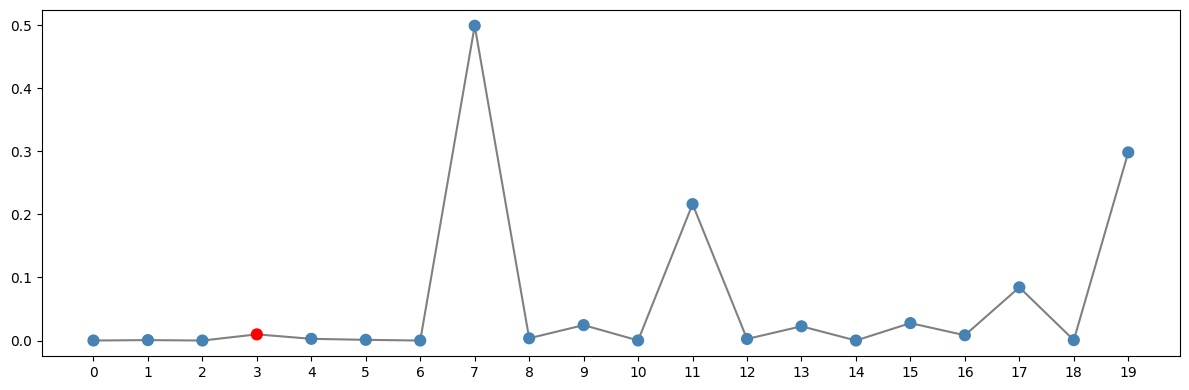

In [137]:
traj_idx = group2[11]
print(traj_idx)
scores_by_traj = get_traj_scores(
    test_scores, 
    grouped_idxs, 
    traj_idx=traj_idx
).cpu().numpy()
idxs_by_traj = grouped_idxs[traj_idx]

plot_scores(scores_by_traj, idxs_by_traj)

In [107]:
traj_idx

37

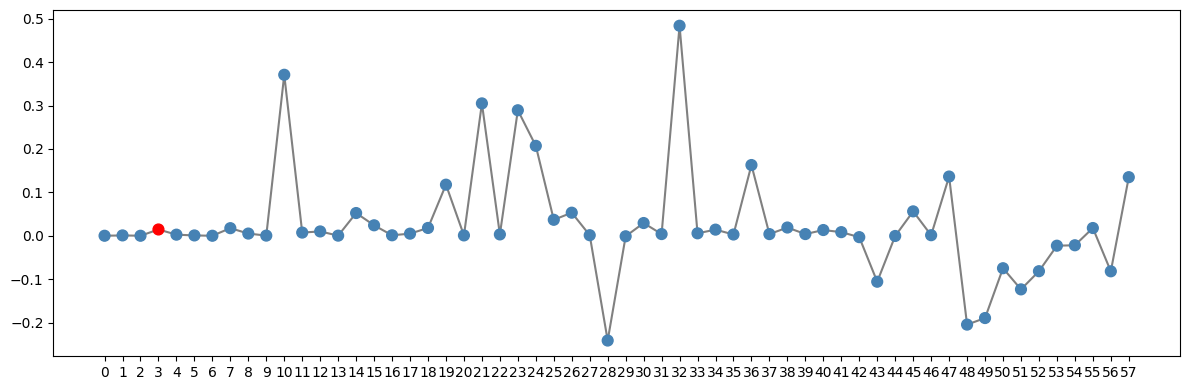

In [131]:
sel_weights = process_weighting(
    all_weights, 
    layer=resolve_layer(position), 
    temp=64, 
    sim="raw_dot"
)
r = reweight_scores(test_scores, test_keeper, sel_weights, gamma=1, k=100)

scores_by_traj = get_traj_scores(
    r, 
    grouped_idxs, 
    traj_idx=traj_idx
).cpu().numpy()
idxs_by_traj = grouped_idxs[traj_idx]

plot_scores(scores_by_traj, idxs_by_traj)

# for g in [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]:
#     r = reweight_scores(test_scores, test_keeper, sel_weights, gamma=g, k=100)
#     n_diff = (r != test_scores).sum().item()
#     print(f"gamma={g:.1f} | temp={temp} | n_diff: {n_diff}")
#     test_metrics = compute_metrics(
#         scores=r, keeper=test_reps.keeper,
#         ks=[1], direction="desc",
#     )
#     print(
#         f"step_acc: {test_metrics['step@1_desc']:.4f} | "
#         f"agent_acc: {test_metrics['agent@1_desc']:.4f}"
#     )